In [1]:
import pandas as pd

train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")

In [2]:
train.head()

,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [ ]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

df = pd.read_csv("train.csv").drop(columns="event_id")

In [ ]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
df = pd.read_csv("train.csv").drop(columns="event_id")
print("Loaded:", df.shape)

In [ ]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df = pd.read_csv('train.csv').drop(columns='event_id')
print('Loaded:', df.shape)

In [4]:
%matplotlib inline
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

df = pd.read_csv('train.csv').drop(columns='event_id')
print('Loaded:', df.shape)

Loaded: (221, 36)


In [5]:
# Step 1 — Inspect
print('Shape:', df.shape)
df.head()

Shape: (221, 36)


,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
0,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,0.03545,0.036086,9.007182,2.11179,8.274971,1.940119,70.130507,0.940469,0.339879,6166.121596,0.205085,0.435052,1.090997e-01,-0.102001,0.102001,-0.435052,7.275611e-02,0.886373,-0.054649,0.054649,-1.937219,-0.106026,19,4,5,18.892512,0
1,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,2930.925956,0.000000,0.000000,-3.887003e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,-0.568898,0.568898,-0.000000,-0.000000,4,4,6,22.048108,1
2,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,3272.375090,0.000000,0.000000,-1.390327e-13,0.000000,0.000000,0.000000,7.965118e-14,0.000000,0.882385,0.882385,0.000000,0.000000,22,4,8,0.888895,1
3,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,64119.871377,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,20,5,8,60.953021,0
4,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,0.00000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,18005.432261,0.000000,0.000000,3.656059e-13,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.934634,0.934634,-0.000000,0.000000,21,5,7,44.990274,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 221 entries, 0 to 220
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   num_perimeters_0_5h           221 non-null    int64  
 1   dt_first_last_0_5h            221 non-null    float64
 2   low_temporal_resolution_0_5h  221 non-null    int64  
 3   area_first_ha                 221 non-null    float64
 4   area_growth_abs_0_5h          221 non-null    float64
 5   area_growth_rel_0_5h          221 non-null    float64
 6   area_growth_rate_ha_per_h     221 non-null    float64
 7   log1p_area_first              221 non-null    float64
 8   log1p_growth                  221 non-null    float64
 9   log_area_ratio_0_5h           221 non-null    float64
 10  relative_growth_0_5h          221 non-null    float64
 11  radial_growth_m               221 non-null    float64
 12  radial_growth_rate_m_per_h    221 non-null    float64
 13  centr

In [7]:
df.dtypes

num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
closing_speed_m_per_h           float64
closing_speed_abs_m_per_h       float64
projected_advance_m             float64


In [8]:
df.describe()

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,2.210000e+02,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,6.543391e-02,1.789087e-01,29.429575,7.770330,44.277876,11.953522,13.771910,0.053662,0.890436,124399.237725,8.079022,-10.286955,-3.030932,2.021403,3.661135,10.286955,-0.967923,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,3.003211e-01,1.302001e+00,144.879769,37.840514,218.759628,58.940466,46.703309,0.285193,0.351904,171302.559054,63.184352,128.652678,41.511198,26.865184,26.690409,128.652678,11.088141,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,-1.437844e-07,-1.437844e-07,-0.000050,-0.000012,0.000000,0.000000,0.000000,-0.999678,-0.974870,306.954551,0.000000,-1706.526611,-566.710918,-51.397494,0.000000,-234.773360,-116.927386,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2965.217571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,31758.581144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,200228.863652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,2.938617e+00,1.788970e+01,1351.378212,352.441687,2045.333109,595.058697,290.139252,0.997687,1.000000,757700.487102,850.735044,234.773360,69.991135,354.120897,354.120897,1706.526611,17.513908,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


In [9]:
df.describe(include='all')

,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,log_area_ratio_0_5h,relative_growth_0_5h,radial_growth_m,radial_growth_rate_m_per_h,centroid_displacement_m,centroid_speed_m_per_h,spread_bearing_deg,spread_bearing_sin,spread_bearing_cos,dist_min_ci_0_5h,dist_std_ci_0_5h,dist_change_ci_0_5h,dist_slope_ci_0_5h,closing_speed_m_per_h,closing_speed_abs_m_per_h,projected_advance_m,dist_accel_m_per_h2,dist_fit_r2_0_5h,alignment_cos,alignment_abs,cross_track_component,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event
count,221.000000,221.000000,221.000000,221.000000,221.000000,2.210000e+02,221.000000,221.000000,221.000000,2.210000e+02,2.210000e+02,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000,221.000000
mean,2.063348,0.979869,0.728507,619.131641,26.332398,1.789087e-01,6.167128,4.683276,0.389346,6.543391e-02,1.789087e-01,29.429575,7.770330,44.277876,11.953522,13.771910,0.053662,0.890436,124399.237725,8.079022,-10.286955,-3.030932,2.021403,3.661135,10.286955,-0.967923,0.046000,-0.004971,0.172704,1.617188,0.551690,15.429864,2.841629,6.782805,37.567626,0.312217
std,2.578859,1.738052,0.445739,1447.723668,187.437018,1.302001e+00,40.467370,2.083529,1.340348,3.003211e-01,1.302001e+00,144.879769,37.840514,218.759628,58.940466,46.703309,0.285193,0.351904,171302.559054,63.184352,128.652678,41.511198,26.865184,26.690409,128.652678,11.088141,0.171690,0.371909,0.329210,37.789199,46.760648,7.921250,1.974217,1.571876,25.902361,0.464450
min,1.000000,0.000000,0.000000,0.037525,-0.000022,-1.437844e-07,-0.000005,0.036838,0.000000,-1.437844e-07,-1.437844e-07,-0.000050,-0.000012,0.000000,0.000000,0.000000,-0.999678,-0.974870,306.954551,0.000000,-1706.526611,-566.710918,-51.397494,0.000000,-234.773360,-116.927386,0.000000,-0.999995,0.000000,-213.411731,-526.597241,0.000000,0.000000,1.000000,0.001220,0.000000
25%,1.000000,0.000000,0.000000,25.219058,0.000000,0.000000e+00,0.000000,3.266487,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2965.217571,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,6.000000,12.242322,0.000000
50%,1.000000,0.000000,1.000000,110.149250,0.000000,0.000000e+00,0.000000,4.710874,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,31758.581144,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,19.000000,3.000000,7.000000,43.109830,0.000000
75%,2.000000,1.356107,1.000000,485.092561,0.000000,0.000000e+00,0.000000,6.186399,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,200228.863652,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.071697,0.000000,0.000000,21.000000,5.000000,8.000000,63.938706,1.000000
max,17.000000,4.994457,1.000000,11942.392115,2508.041442,1.788970e+01,520.443033,9.387933,7.827656,2.938617e+00,1.788970e+01,1351.378212,352.441687,2045.333109,595.058697,290.139252,0.997687,1.000000,757700.487102,850.735044,234.773360,69.991135,354.120897,354.120897,1706.526611,17.513908,0.917415,0.994594,0.999995,277.110446,383.099186,23.000000,6.000000,9.000000,66.994474,1.000000


In [10]:
print('Unique values per column:')
df.nunique().sort_values()

Unique values per column:


event                             2
low_temporal_resolution_0_5h      2
event_start_dayofweek             7
event_start_month                 9
num_perimeters_0_5h              12
dist_change_ci_0_5h              19
projected_advance_m              19
closing_speed_abs_m_per_h        19
closing_speed_m_per_h            19
dist_fit_r2_0_5h                 20
dist_std_ci_0_5h                 20
event_start_hour                 22
log1p_growth                     25
along_track_speed                26
cross_track_component            26
area_growth_abs_0_5h             26
area_growth_rel_0_5h             26
relative_growth_0_5h             26
area_growth_rate_ha_per_h        26
log_area_ratio_0_5h              26
spread_bearing_sin               26
radial_growth_m                  26
radial_growth_rate_m_per_h       26
spread_bearing_cos               26
centroid_speed_m_per_h           26
spread_bearing_deg               26
centroid_displacement_m          26
dist_accel_m_per_h2         

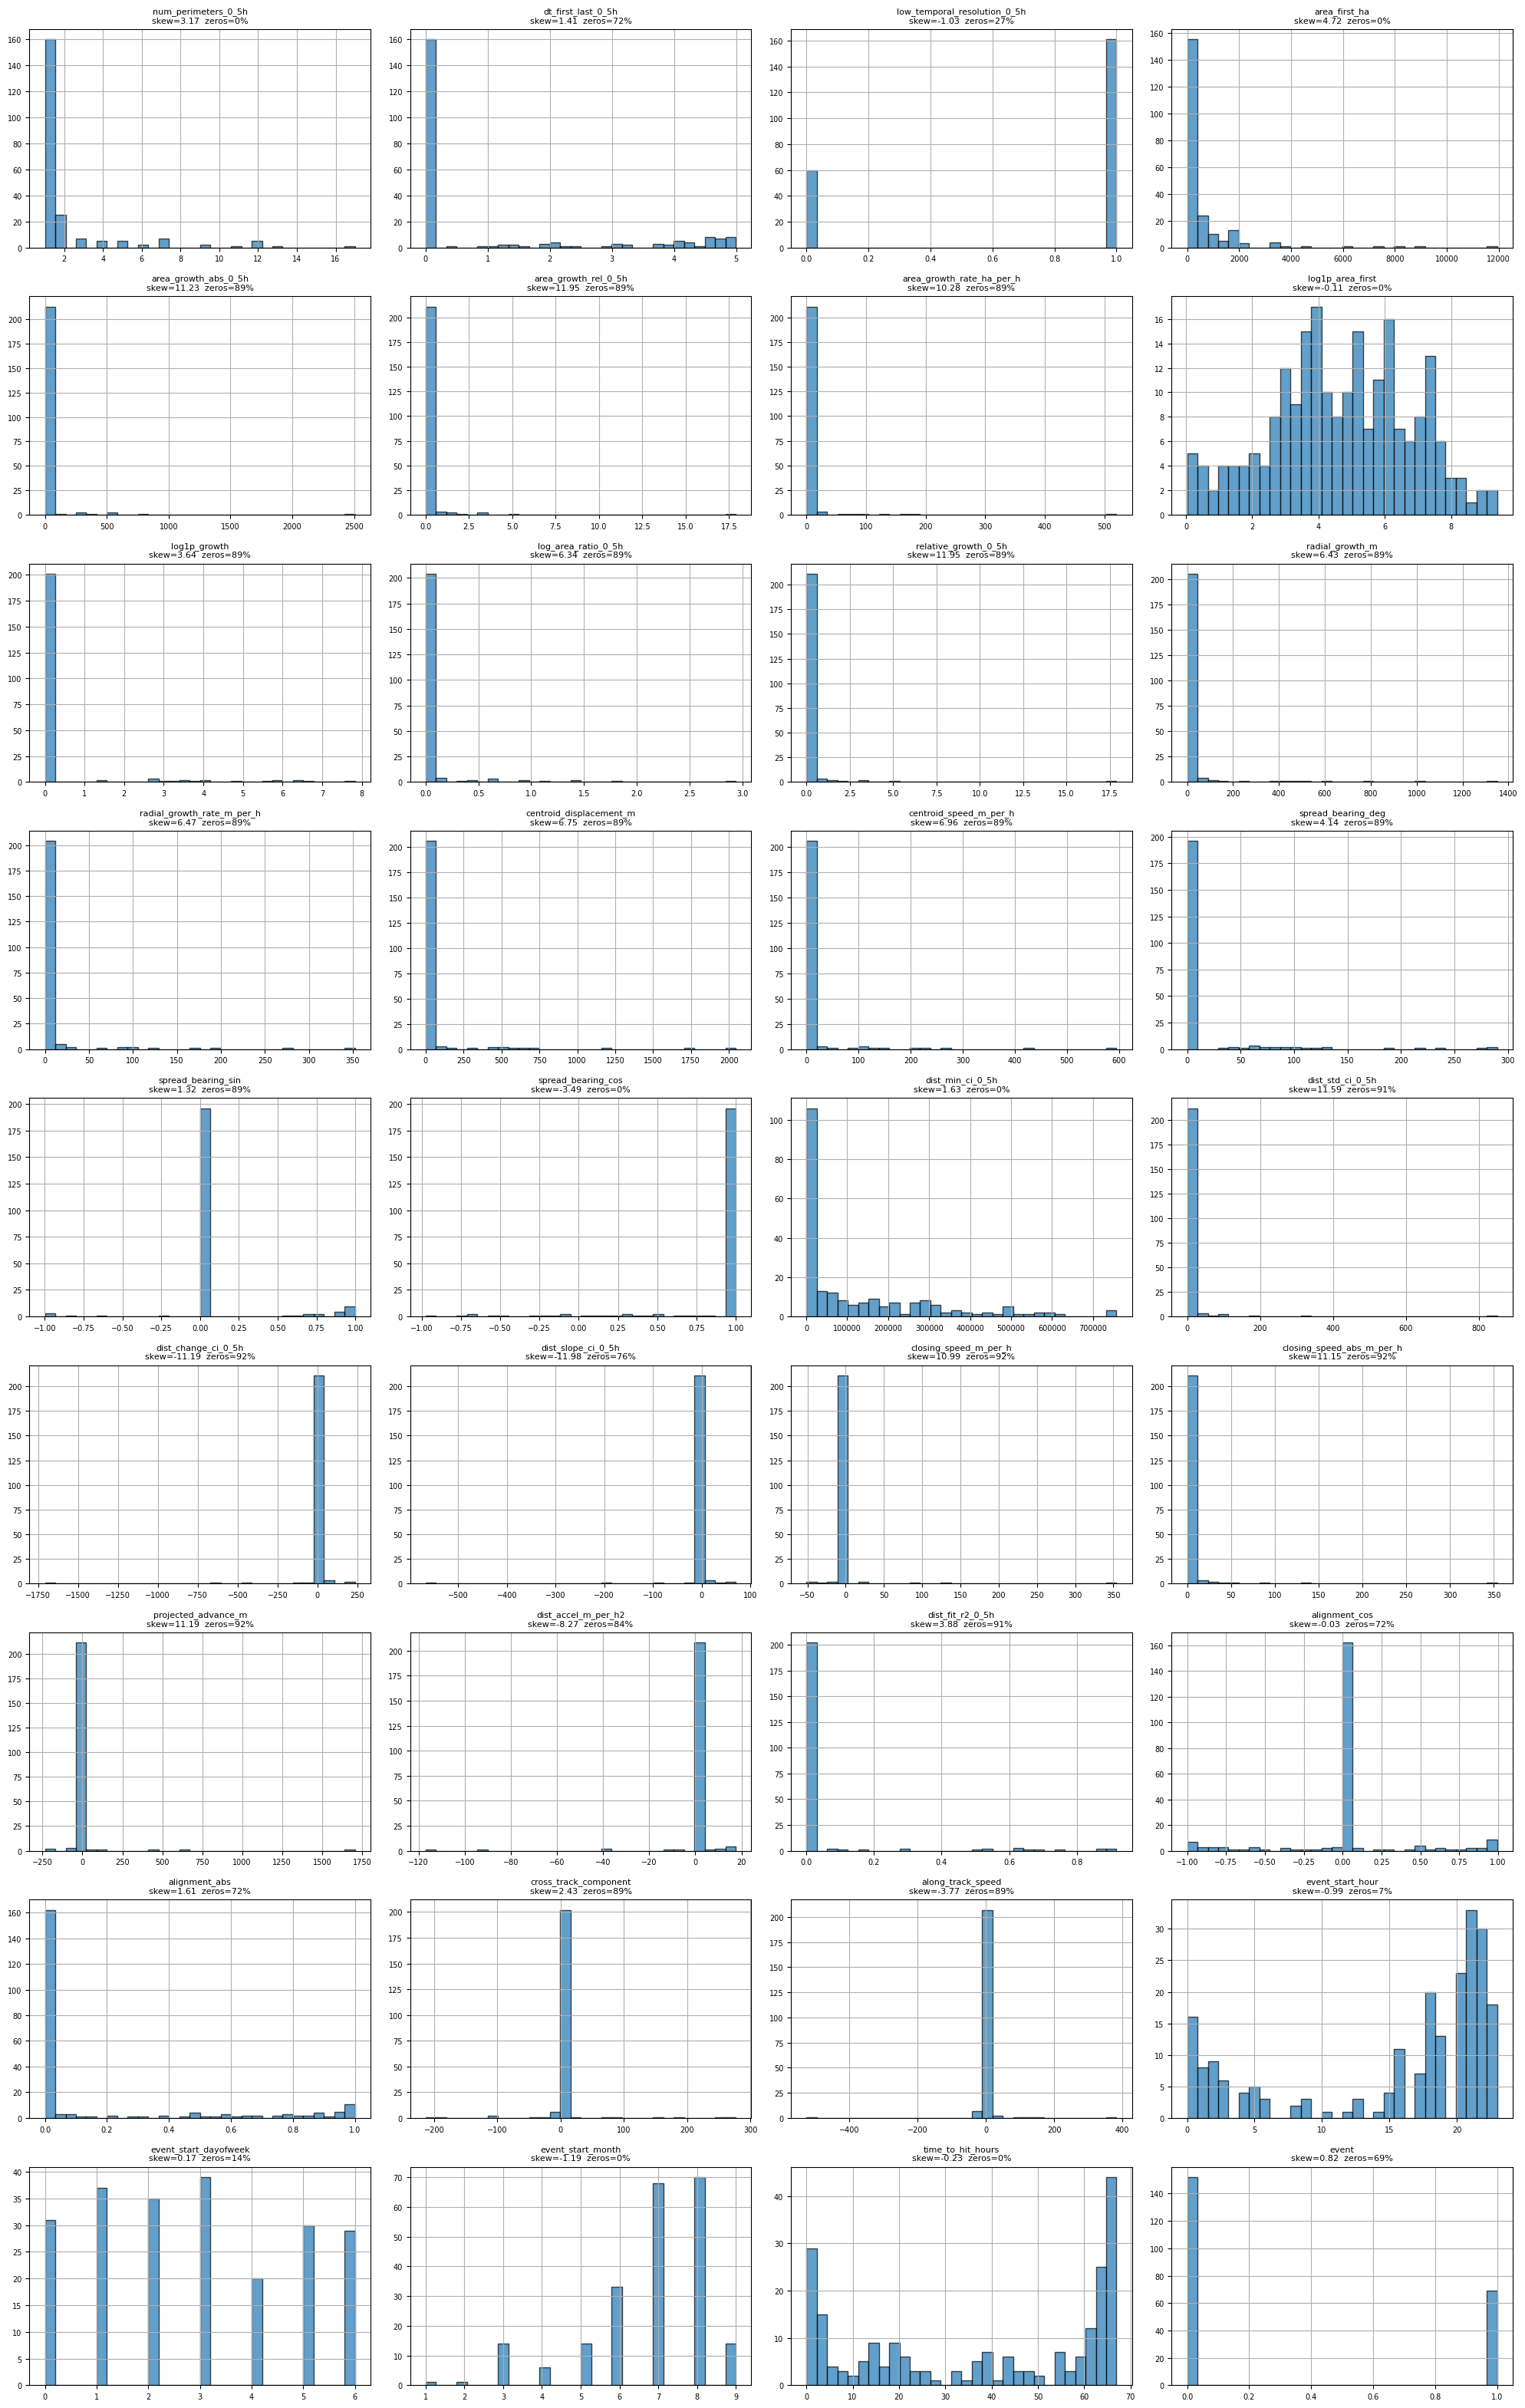

In [11]:
cols = df.columns.tolist()
ncols = 4
nrows = int(np.ceil(len(cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7)
    skew = df[col].skew()
    zeros_pct = (df[col] == 0).mean() * 100
    ax.set_title(f'{col}\nskew={skew:.2f}  zeros={zeros_pct:.0f}%', fontsize=8)
    ax.tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Target value counts:
event
0    152
1     69
Name: count, dtype: int64

Positive rate: 31.22%


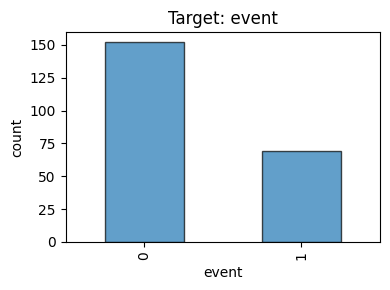

In [12]:
# Target class balance
print('Target value counts:')
print(df['event'].value_counts())
print(f'\nPositive rate: {df["event"].mean():.2%}')

fig, ax = plt.subplots(figsize=(4, 3))
df['event'].value_counts().plot(kind='bar', ax=ax, edgecolor='black', alpha=0.7)
ax.set_title('Target: event')
ax.set_ylabel('count')
plt.tight_layout()
plt.show()

In [13]:
# Summary table: skew and zero-inflation
summary = pd.DataFrame({
    'skew': df.skew(),
    'pct_zero': (df == 0).mean() * 100,
    'zero_inflated': (df == 0).mean() > 0.5
}).sort_values('pct_zero', ascending=False)
print(f'Zero-inflated columns (>50% zeros): {summary["zero_inflated"].sum()}')
summary.head(20)

Zero-inflated columns (>50% zeros): 26


,skew,pct_zero,zero_inflated
projected_advance_m,11.187420,91.855204,True
closing_speed_abs_m_per_h,11.152232,91.855204,True
closing_speed_m_per_h,10.994165,91.855204,True
dist_change_ci_0_5h,-11.187420,91.855204,True
dist_fit_r2_0_5h,3.884857,91.402715,True
dist_std_ci_0_5h,11.589398,91.402715,True
log1p_growth,3.635148,89.140271,True
spread_bearing_deg,4.141749,88.687783,True
centroid_displacement_m,6.753091,88.687783,True
cross_track_component,2.425414,88.687783,True


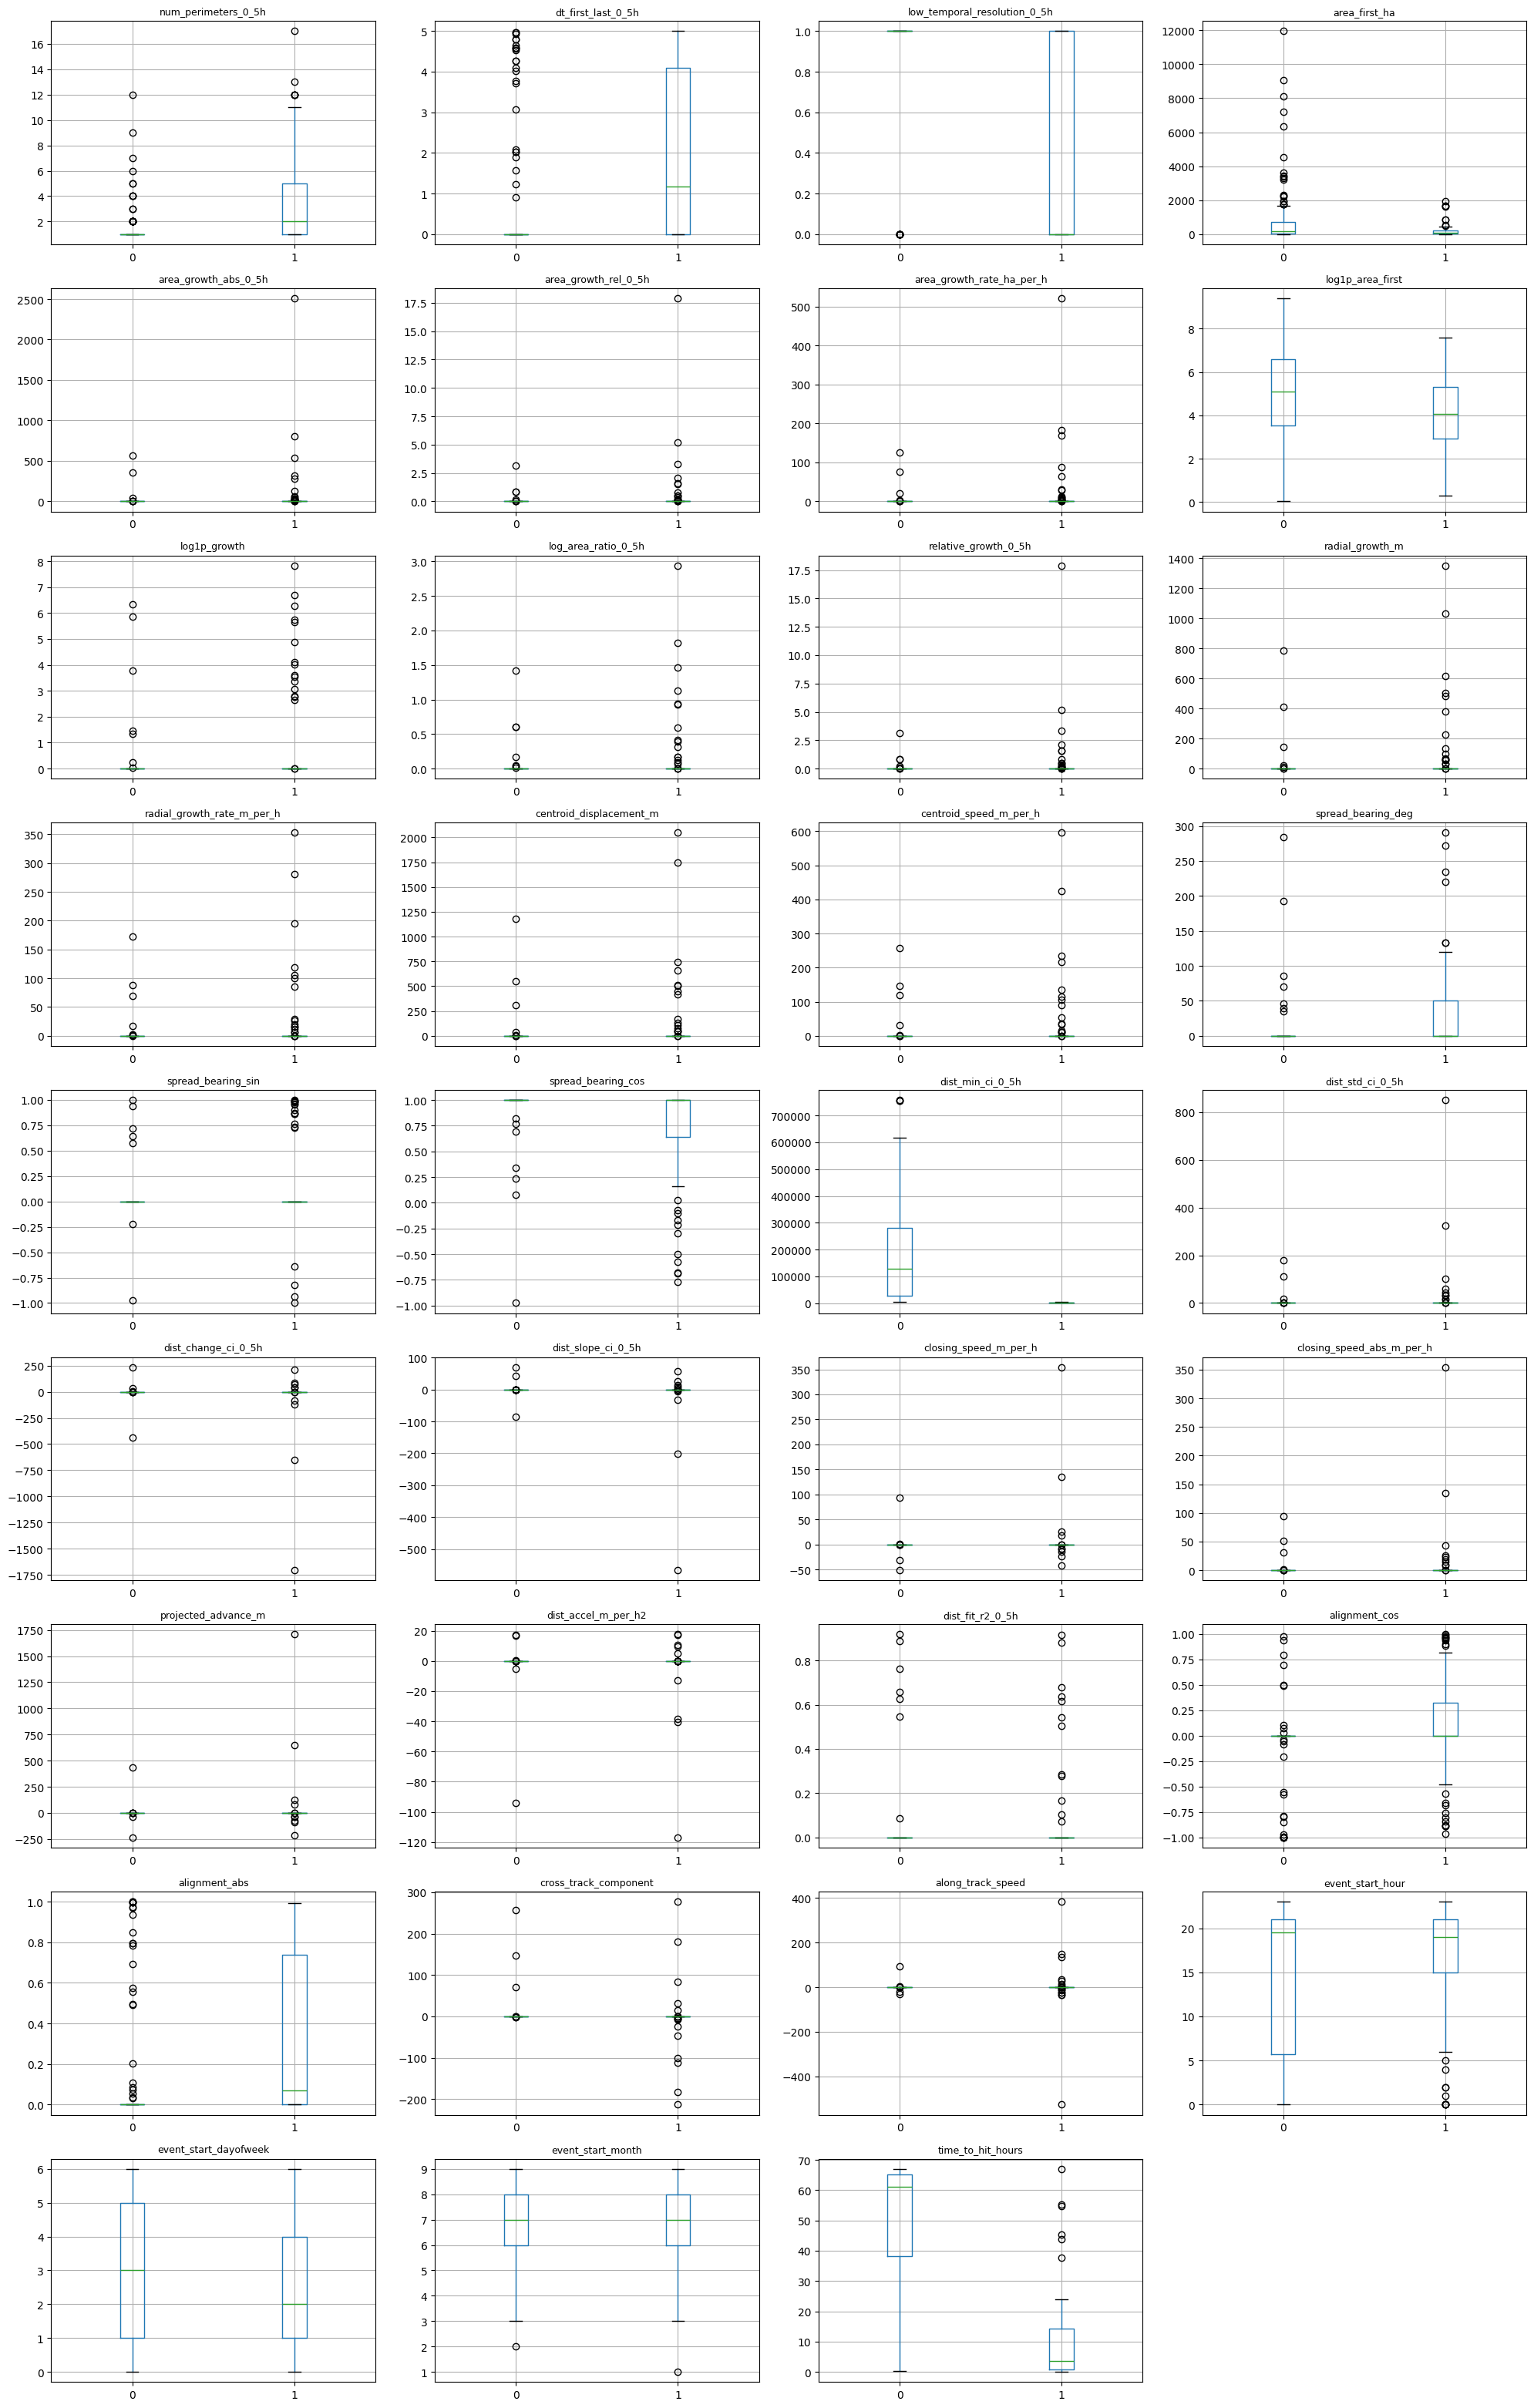

In [14]:
# Step 3 — Bivariate: box plots
feature_cols = [c for c in df.columns if c != 'event']
n = len(feature_cols)
ncols = 4
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 3.5))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    df.boxplot(column=col, by='event', ax=ax)
    ax.set_title(col, fontsize=9)
    ax.set_xlabel('')
    fig.suptitle('')

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

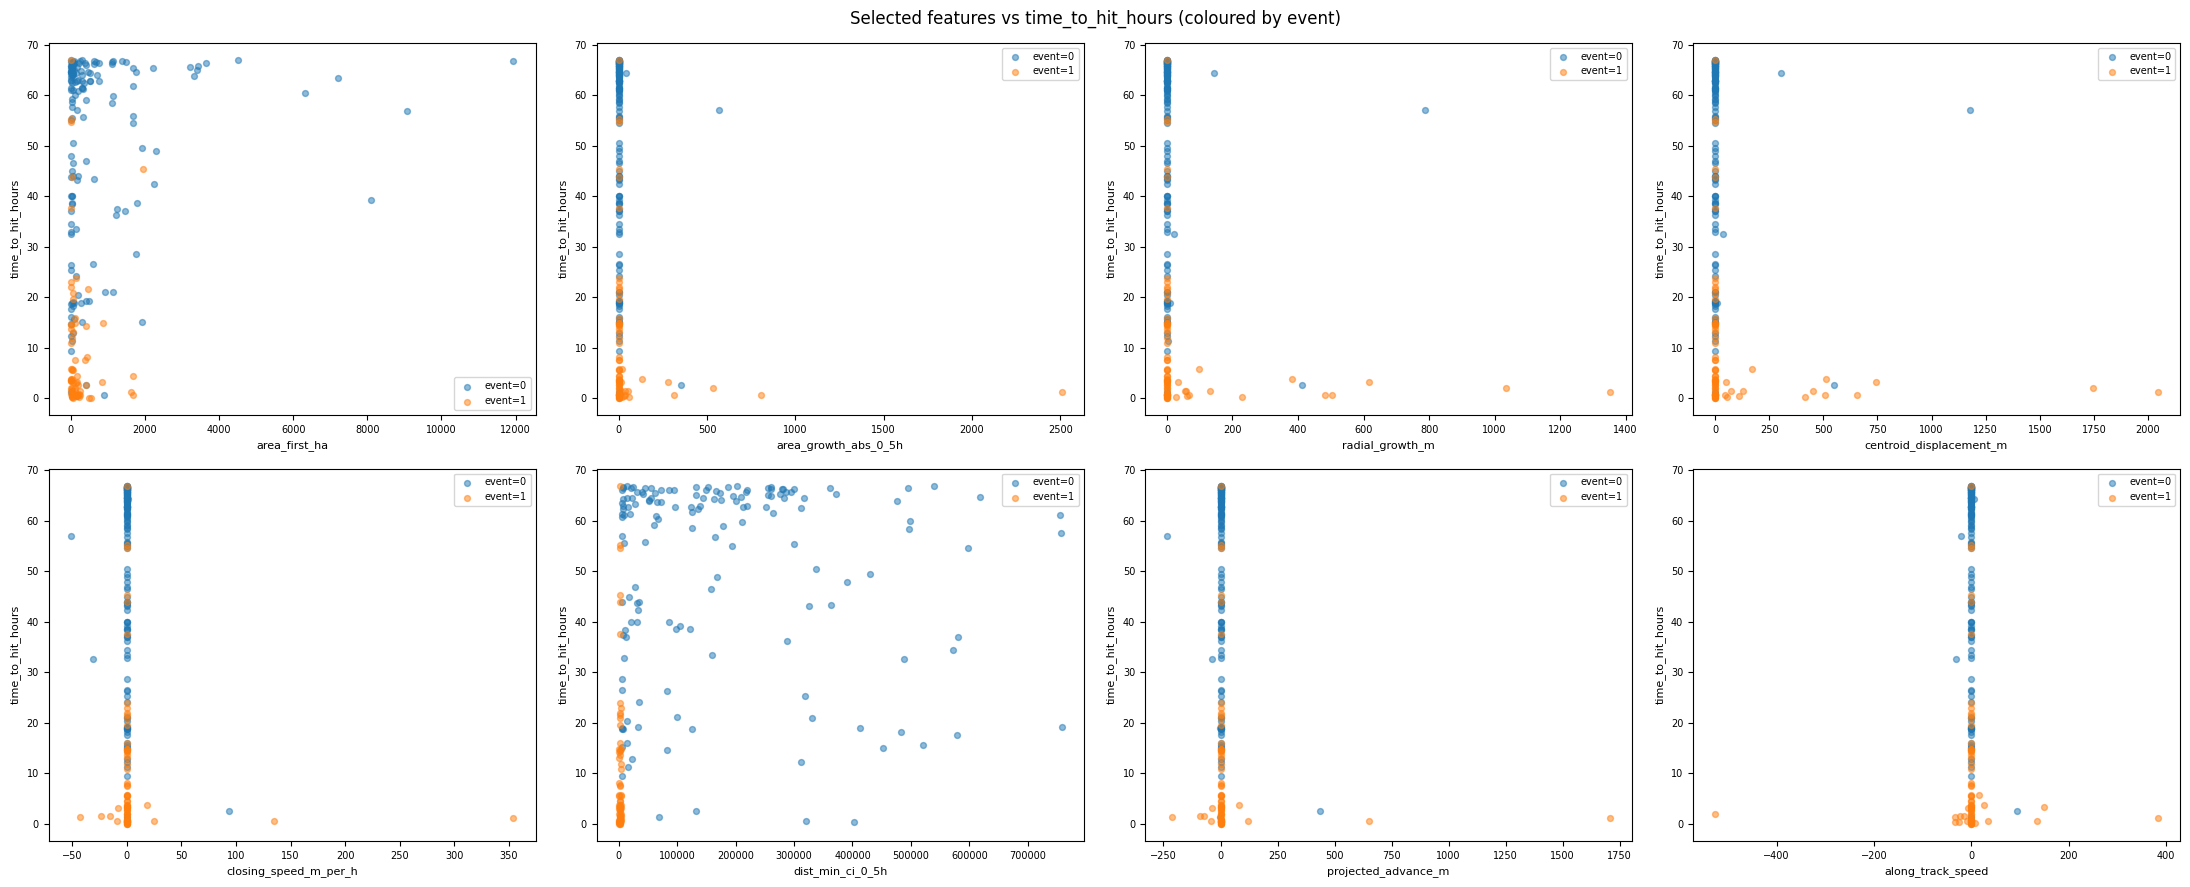

In [15]:
# Scatter plots: selected features vs time_to_hit_hours, coloured by event
scatter_feats = [
    'area_first_ha', 'area_growth_abs_0_5h', 'radial_growth_m',
    'centroid_displacement_m', 'closing_speed_m_per_h', 'dist_min_ci_0_5h',
    'projected_advance_m', 'along_track_speed'
]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()
for i, col in enumerate(scatter_feats):
    ax = axes[i]
    for ev, colour in [(0, 'tab:blue'), (1, 'tab:orange')]:
        sub = df[df['event'] == ev]
        ax.scatter(sub[col], sub['time_to_hit_hours'], alpha=0.5,
                   label=f'event={ev}', s=18, c=colour)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel('time_to_hit_hours', fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle('Selected features vs time_to_hit_hours (coloured by event)', fontsize=12)
plt.tight_layout()
plt.show()

In [16]:
# Step 4 — Outlier Detection (IQR)
feature_cols = [c for c in df.columns if c != 'event']
rows = []
for col in feature_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lo = Q1 - 1.5 * IQR
    hi = Q3 + 1.5 * IQR
    mask = (df[col] < lo) | (df[col] > hi)
    n_out = mask.sum()
    rows.append({
        'feature': col,
        'Q1': round(Q1, 4), 'Q3': round(Q3, 4), 'IQR': round(IQR, 4),
        'lower': round(lo, 4), 'upper': round(hi, 4),
        'n_outliers': n_out,
        'pct_outliers': round(n_out / len(df) * 100, 1),
        'zero_inflated_IQR': IQR == 0
    })

outlier_df = pd.DataFrame(rows).sort_values('n_outliers', ascending=False)

print('=== Features with IQR > 0 (true continuous outliers) ===')
display(outlier_df[~outlier_df['zero_inflated_IQR'] & (outlier_df['n_outliers'] > 0)])

print('\n=== Zero-inflated features (IQR=0, non-zero values flagged — these are signal, not outliers) ===')
display(outlier_df[outlier_df['zero_inflated_IQR'] & (outlier_df['n_outliers'] > 0)])

print('\n=== Features with no outliers ===')
display(outlier_df[outlier_df['n_outliers'] == 0])

=== Features with IQR > 0 (true continuous outliers) ===


,feature,Q1,Q3,IQR,lower,upper,n_outliers,pct_outliers,zero_inflated_IQR
28,alignment_abs,0.0000,0.0717,0.0717,-0.1075,0.1792,51,23.1,False
1,dt_first_last_0_5h,0.0000,1.3561,1.3561,-2.0342,3.3903,38,17.2,False
3,area_first_ha,25.2191,485.0926,459.8735,-664.5912,1174.9028,32,14.5,False
0,num_perimeters_0_5h,1.0000,2.0000,1.0000,-0.5000,3.5000,29,13.1,False
18,dist_min_ci_0_5h,2965.2176,200228.8637,197263.6461,-292930.2516,496124.3328,12,5.4,False
33,event_start_month,6.0000,8.0000,2.0000,3.0000,11.0000,2,0.9,False



=== Zero-inflated features (IQR=0, non-zero values flagged — these are signal, not outliers) ===


,feature,Q1,Q3,IQR,lower,upper,n_outliers,pct_outliers,zero_inflated_IQR
27,alignment_cos,0.0,0.0,0.0,0.0,0.0,61,27.6,True
21,dist_slope_ci_0_5h,0.0,0.0,0.0,0.0,0.0,52,23.5,True
25,dist_accel_m_per_h2,0.0,0.0,0.0,0.0,0.0,35,15.8,True
13,centroid_displacement_m,0.0,0.0,0.0,0.0,0.0,25,11.3,True
30,along_track_speed,0.0,0.0,0.0,0.0,0.0,25,11.3,True
29,cross_track_component,0.0,0.0,0.0,0.0,0.0,25,11.3,True
16,spread_bearing_sin,0.0,0.0,0.0,0.0,0.0,25,11.3,True
15,spread_bearing_deg,0.0,0.0,0.0,0.0,0.0,25,11.3,True
14,centroid_speed_m_per_h,0.0,0.0,0.0,0.0,0.0,25,11.3,True
17,spread_bearing_cos,1.0,1.0,0.0,1.0,1.0,25,11.3,True



=== Features with no outliers ===


,feature,Q1,Q3,IQR,lower,upper,n_outliers,pct_outliers,zero_inflated_IQR
7,log1p_area_first,3.2665,6.1864,2.9199,-1.1134,10.5663,0,0.0,False
2,low_temporal_resolution_0_5h,0.0000,1.0000,1.0000,-1.5000,2.5000,0,0.0,False
31,event_start_hour,9.0000,21.0000,12.0000,-9.0000,39.0000,0,0.0,False
32,event_start_dayofweek,1.0000,5.0000,4.0000,-5.0000,11.0000,0,0.0,False
34,time_to_hit_hours,12.2423,63.9387,51.6964,-65.3023,141.4833,0,0.0,False


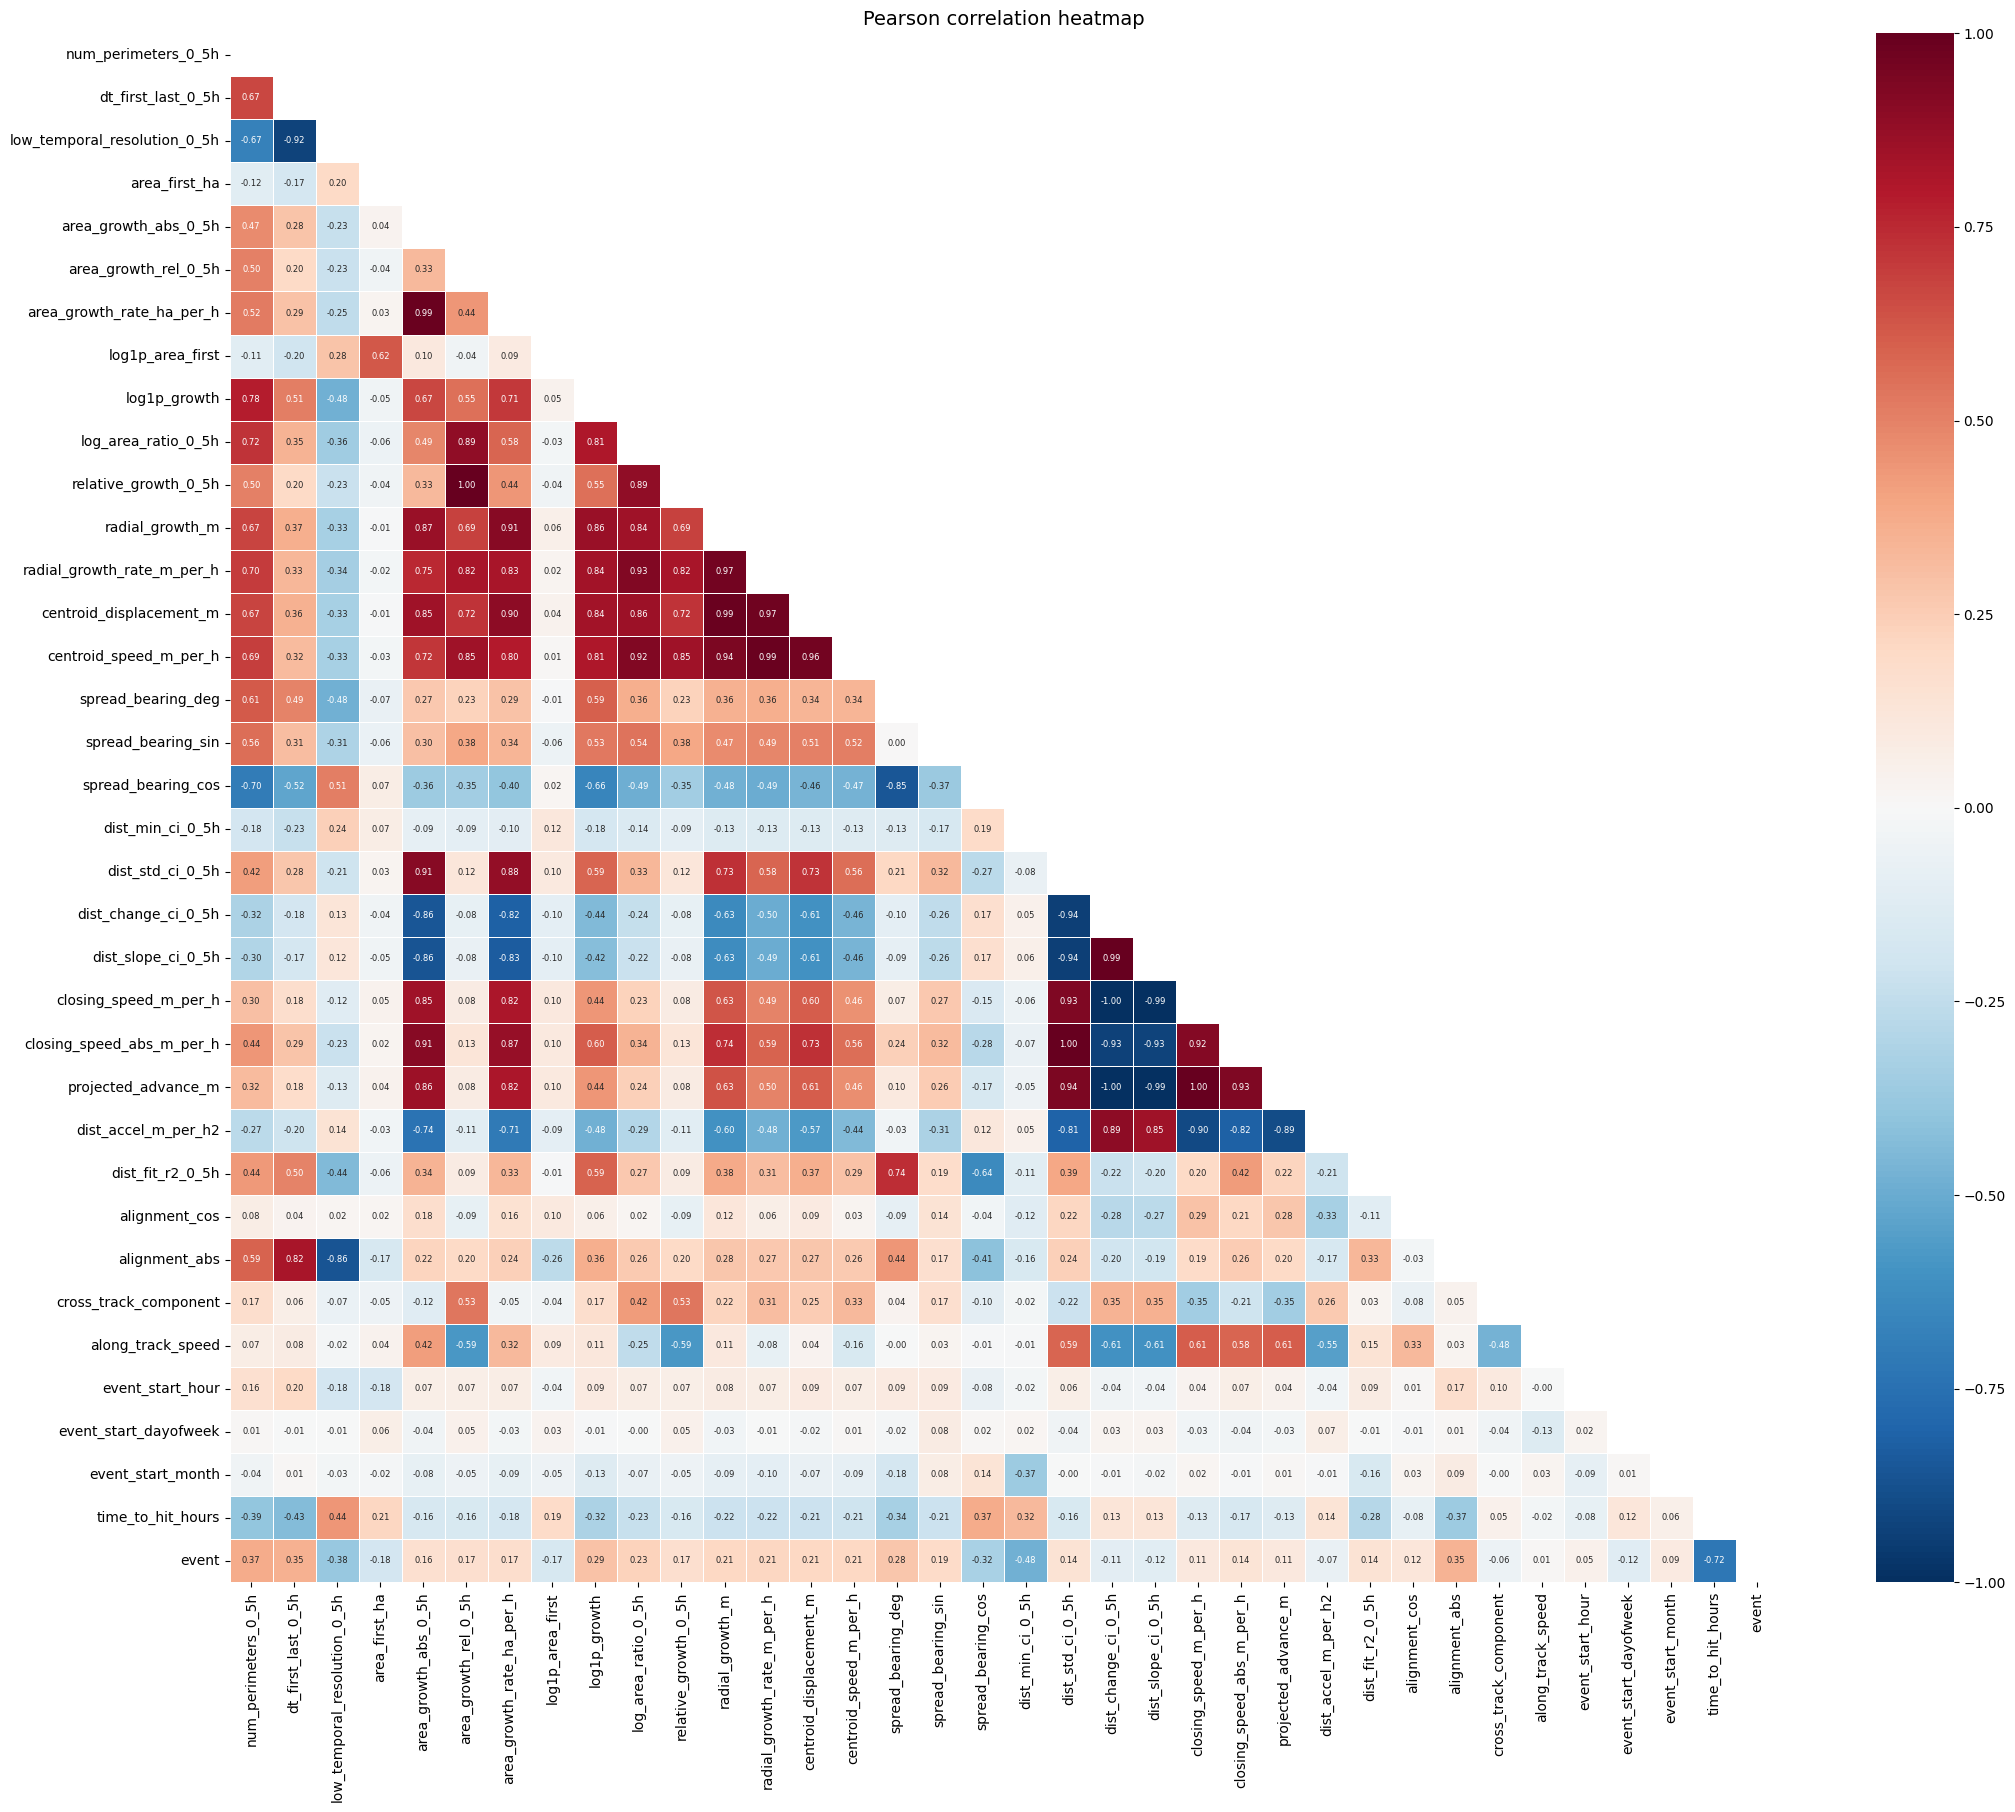

In [17]:
# 5a. Correlation heatmap
corr = df.corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 6}, ax=ax)
ax.set_title('Pearson correlation heatmap', fontsize=14)
plt.tight_layout()
plt.show()

In [18]:
# 5b. Redundant feature pairs
pairs = []
cols = corr.columns
for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr.iloc[i, j]
        if abs(r) >= 0.8:
            pairs.append({
                'feature_1': cols[i], 'feature_2': cols[j],
                'r': round(r, 4), 'abs_r': round(abs(r), 4),
                'band': 'DROP one (>=0.9)' if abs(r) >= 0.9 else 'Investigate (0.8-0.9)'
            })

pair_df = pd.DataFrame(pairs).sort_values('abs_r', ascending=False)
print(f'Pairs with |r| >= 0.9: {(pair_df["abs_r"] >= 0.9).sum()}')
print(f'Pairs with 0.8 <= |r| < 0.9: {((pair_df["abs_r"] >= 0.8) & (pair_df["abs_r"] < 0.9)).sum()}')
pair_df

Pairs with |r| >= 0.9: 29
Pairs with 0.8 <= |r| < 0.9: 36


,feature_1,feature_2,r,abs_r,band
53,dist_change_ci_0_5h,projected_advance_m,-1.0000,1.0000,DROP one (>=0.9)
13,area_growth_rel_0_5h,relative_growth_0_5h,1.0000,1.0000,DROP one (>=0.9)
60,closing_speed_m_per_h,projected_advance_m,0.9982,0.9982,DROP one (>=0.9)
51,dist_change_ci_0_5h,closing_speed_m_per_h,-0.9982,0.9982,DROP one (>=0.9)
47,dist_std_ci_0_5h,closing_speed_abs_m_per_h,0.9969,0.9969,DROP one (>=0.9)
...,...,...,...,...,...
63,closing_speed_abs_m_per_h,dist_accel_m_per_h2,-0.8186,0.8186,Investigate (0.8-0.9)
22,area_growth_rate_ha_per_h,closing_speed_m_per_h,0.8154,0.8154,Investigate (0.8-0.9)
29,log1p_growth,centroid_speed_m_per_h,0.8120,0.8120,Investigate (0.8-0.9)
49,dist_std_ci_0_5h,dist_accel_m_per_h2,-0.8110,0.8110,Investigate (0.8-0.9)


In [19]:
# 5c. Drop recommendations
target_abs = corr['event'].drop('event').abs()

to_drop = set()
decisions = []

for _, row in pair_df[pair_df['abs_r'] >= 0.9].iterrows():
    f1, f2 = row['feature_1'], row['feature_2']
    if f1 == 'event' or f2 == 'event':
        continue
    tc1, tc2 = target_abs.get(f1, 0), target_abs.get(f2, 0)
    sk1, sk2 = abs(df[f1].skew()), abs(df[f2].skew())
    # score: lower is better (lower skew, higher target corr)
    s1 = sk1 - tc1 * 10
    s2 = sk2 - tc2 * 10
    keep, drop = (f1, f2) if s1 <= s2 else (f2, f1)
    to_drop.add(drop)
    decisions.append({'pair': f'{f1}  vs  {f2}', 'r': row['r'],
                      'keep': keep, 'drop': drop,
                      'target_corr_keep': round(tc1 if keep == f1 else tc2, 4),
                      'target_corr_drop': round(tc2 if keep == f1 else tc1, 4)})

dec_df = pd.DataFrame(decisions)
print(f'Total features recommended to drop: {len(to_drop)}')
print(sorted(to_drop))
dec_df

Total features recommended to drop: 14
['area_growth_abs_0_5h', 'area_growth_rate_ha_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'closing_speed_abs_m_per_h', 'closing_speed_m_per_h', 'dist_change_ci_0_5h', 'dist_slope_ci_0_5h', 'dist_std_ci_0_5h', 'dt_first_last_0_5h', 'projected_advance_m', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'relative_growth_0_5h']


,pair,r,keep,drop,target_corr_keep,target_corr_drop
0,dist_change_ci_0_5h vs projected_advance_m,-1.0000,dist_change_ci_0_5h,projected_advance_m,0.1064,0.1064
1,area_growth_rel_0_5h vs relative_growth_0_5h,1.0000,area_growth_rel_0_5h,relative_growth_0_5h,0.1660,0.1660
2,closing_speed_m_per_h vs projected_advance_m,0.9982,closing_speed_m_per_h,projected_advance_m,0.1074,0.1064
3,dist_change_ci_0_5h vs closing_speed_m_per_h,-0.9982,closing_speed_m_per_h,dist_change_ci_0_5h,0.1074,0.1064
4,dist_std_ci_0_5h vs closing_speed_abs_m_per_h,0.9969,closing_speed_abs_m_per_h,dist_std_ci_0_5h,0.1387,0.1420
5,dist_slope_ci_0_5h vs projected_advance_m,-0.9931,projected_advance_m,dist_slope_ci_0_5h,0.1064,0.1153
6,dist_slope_ci_0_5h vs closing_speed_m_per_h,-0.9931,closing_speed_m_per_h,dist_slope_ci_0_5h,0.1074,0.1153
7,dist_change_ci_0_5h vs dist_slope_ci_0_5h,0.9931,dist_change_ci_0_5h,dist_slope_ci_0_5h,0.1064,0.1153
8,area_growth_abs_0_5h vs area_growth_rate_ha_...,0.9913,area_growth_rate_ha_per_h,area_growth_abs_0_5h,0.1724,0.1583
9,radial_growth_m vs centroid_displacement_m,0.9891,radial_growth_m,centroid_displacement_m,0.2093,0.2080


Feature ranking (after removing redundant features):

   1. time_to_hit_hours                    |r| = 0.7195  (STRONG)
   2. dist_min_ci_0_5h                     |r| = 0.4814  (STRONG)
   3. low_temporal_resolution_0_5h         |r| = 0.3791  (STRONG)
   4. num_perimeters_0_5h                  |r| = 0.3705  (STRONG)
   5. alignment_abs                        |r| = 0.3491  (STRONG)
   6. spread_bearing_cos                   |r| = 0.3232  (STRONG)
   7. log1p_growth                         |r| = 0.2927  (MODERATE)
   8. spread_bearing_deg                   |r| = 0.2810  (MODERATE)
   9. log_area_ratio_0_5h                  |r| = 0.2293  (MODERATE)
  10. spread_bearing_sin                   |r| = 0.1883  (MODERATE)
  11. area_first_ha                        |r| = 0.1813  (MODERATE)
  12. log1p_area_first                     |r| = 0.1679  (MODERATE)
  13. area_growth_rel_0_5h                 |r| = 0.1660  (MODERATE)
  14. dist_fit_r2_0_5h                     |r| = 0.1431  (WEAK)
  15. alig

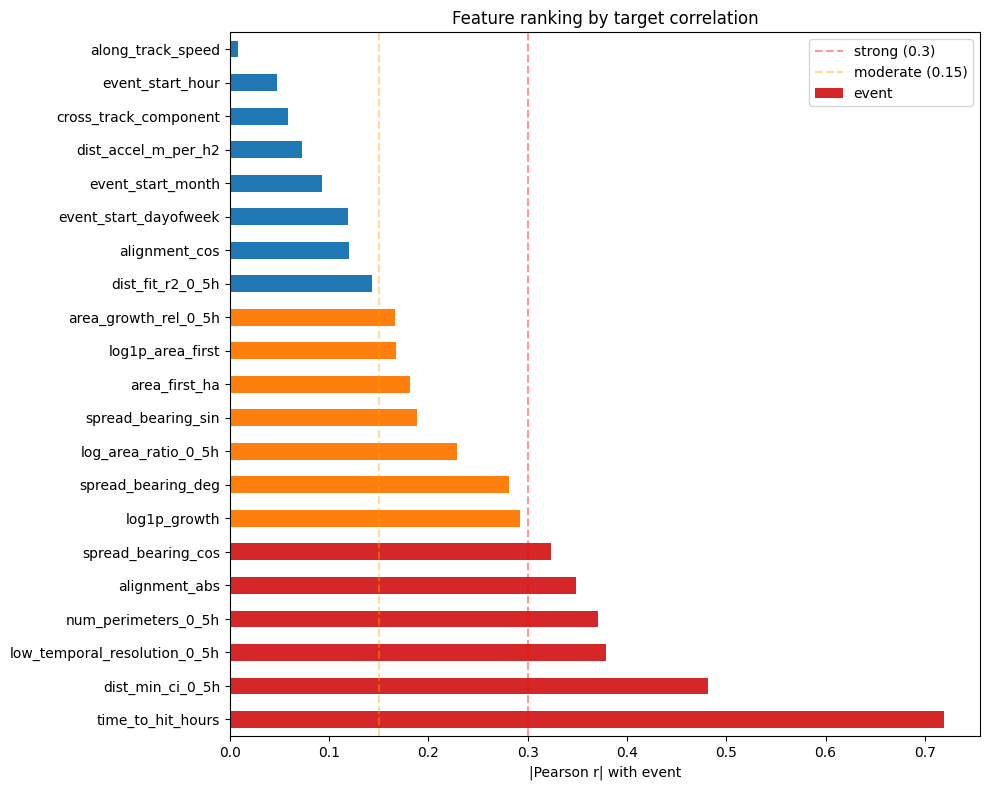

In [20]:
# 5d. Feature ranking
remaining = [c for c in target_abs.index if c not in to_drop]
ranking = target_abs[remaining].sort_values(ascending=False)

print('Feature ranking (after removing redundant features):\n')
for i, (feat, r) in enumerate(ranking.items(), 1):
    tag = 'STRONG' if r >= 0.3 else 'MODERATE' if r >= 0.15 else 'WEAK'
    print(f'  {i:2d}. {feat:<35s}  |r| = {r:.4f}  ({tag})')

fig, ax = plt.subplots(figsize=(10, 8))
colours = ['#d62728' if v >= 0.3 else '#ff7f0e' if v >= 0.15 else '#1f77b4'
           for v in ranking.values]
ranking.plot(kind='barh', ax=ax, color=colours)
ax.set_xlabel('|Pearson r| with event')
ax.set_title('Feature ranking by target correlation')
ax.axvline(0.3, color='red', ls='--', alpha=0.4, label='strong (0.3)')
ax.axvline(0.15, color='orange', ls='--', alpha=0.4, label='moderate (0.15)')
ax.legend()
plt.tight_layout()
plt.show()

In [21]:
# --- Non-linearity: Pearson vs Spearman ---
pearson  = df.corr()['event'].drop('event')
spearman = df.corr(method='spearman')['event'].drop('event')

nl = pd.DataFrame({'pearson': pearson.abs(), 'spearman': spearman.abs(),
                    'gap': spearman.abs() - pearson.abs()}).sort_values('gap', ascending=False)
print('=== Non-linear signals (Spearman >> Pearson) ===')
display(nl[nl['gap'] > 0.05])

=== Non-linear signals (Spearman >> Pearson) ===


,pearson,spearman,gap
dist_min_ci_0_5h,0.481379,0.802637,0.321258
area_growth_abs_0_5h,0.158327,0.275955,0.117628
area_growth_rel_0_5h,0.165975,0.275398,0.109423
relative_growth_0_5h,0.165975,0.275398,0.109423
centroid_displacement_m,0.207992,0.316590,0.108598
centroid_speed_m_per_h,0.209254,0.314641,0.105388
area_growth_rate_ha_per_h,0.172416,0.276233,0.103817
dist_std_ci_0_5h,0.141964,0.213284,0.071320
dist_slope_ci_0_5h,0.115274,0.184241,0.068966
radial_growth_m,0.209343,0.276233,0.066891


In [22]:
# --- Outlier-driven correlation: full vs trimmed (5th-95th pctl) ---
print('=== Outlier-driven correlation check ===')
shifts = {}
for col in remaining:
    lo, hi = df[col].quantile(0.05), df[col].quantile(0.95)
    m = (df[col] >= lo) & (df[col] <= hi)
    if m.sum() > 10:
        shifts[col] = df.loc[m, col].corr(df.loc[m, 'event'])

trim_df = pd.DataFrame({'full_r': pearson[list(shifts)],
                         'trimmed_r': pd.Series(shifts)})
trim_df['shift'] = (trim_df['trimmed_r'].abs() - trim_df['full_r'].abs()).round(4)
display(trim_df[trim_df['shift'].abs() > 0.05].sort_values('shift'))

=== Outlier-driven correlation check ===


,full_r,trimmed_r,shift
spread_bearing_cos,-0.323189,-0.188729,-0.1345
alignment_cos,0.119933,-0.020332,-0.0996
area_growth_rel_0_5h,0.165975,0.217289,0.0513
alignment_abs,0.349115,0.419021,0.0699
dist_fit_r2_0_5h,0.143101,0.232597,0.0895


In [23]:
# --- Leakage check: time_to_hit_hours ---
print('=== Potential leakage ===')
print(f'time_to_hit_hours  Pearson r with event: {pearson["time_to_hit_hours"]:.4f}')
print(f'time_to_hit_hours  Spearman r with event: {spearman["time_to_hit_hours"]:.4f}')
print()
print('time_to_hit_hours is the strongest single predictor by far (|r|=0.72).')
print('If it encodes information that is only available AFTER the outcome is known,')
print('it constitutes target leakage and must be excluded from modelling.')
print()
print('event_id was already dropped (identifier, not a feature).')

=== Potential leakage ===
time_to_hit_hours  Pearson r with event: -0.7195
time_to_hit_hours  Spearman r with event: -0.6866

time_to_hit_hours is the strongest single predictor by far (|r|=0.72).
If it encodes information that is only available AFTER the outcome is known,
it constitutes target leakage and must be excluded from modelling.

event_id was already dropped (identifier, not a feature).


In [24]:
# --- Simpson's paradox ---
print("=== Simpson's paradox check ===")
print('Checking whether feature–target correlations reverse in subgroups.\n')

top_feats = ranking.head(8).index.tolist()
group_cols = ['event_start_month', 'low_temporal_resolution_0_5h', 'event_start_dayofweek']

for gc in group_cols:
    reversals = []
    for gval, gdf in df.groupby(gc):
        if len(gdf) < 10:
            continue
        for feat in top_feats:
            if feat == gc:
                continue
            gr = gdf[feat].corr(gdf['event'])
            overall = pearson[feat]
            if not np.isnan(gr) and np.sign(gr) != np.sign(overall) and abs(gr) > 0.1:
                reversals.append(
                    f'  {feat}: overall r={overall:.3f}, '
                    f'but {gc}={gval} (n={len(gdf)}): r={gr:.3f}'
                )
    if reversals:
        print(f'Reversals when grouping by {gc}:')
        for r in reversals:
            print(r)
    else:
        print(f'No reversals for {gc}')
    print()

=== Simpson's paradox check ===
Checking whether feature–target correlations reverse in subgroups.

Reversals when grouping by event_start_month:
  spread_bearing_cos: overall r=-0.323, but event_start_month=5 (n=14): r=0.175
  spread_bearing_deg: overall r=0.281, but event_start_month=5 (n=14): r=-0.121
  alignment_abs: overall r=0.349, but event_start_month=9 (n=14): r=-0.106

No reversals for low_temporal_resolution_0_5h

Reversals when grouping by event_start_dayofweek:
  log1p_growth: overall r=0.293, but event_start_dayofweek=1 (n=37): r=-0.145
  spread_bearing_cos: overall r=-0.323, but event_start_dayofweek=4 (n=20): r=0.192
  log1p_growth: overall r=0.293, but event_start_dayofweek=4 (n=20): r=-0.192
  spread_bearing_deg: overall r=0.281, but event_start_dayofweek=4 (n=20): r=-0.162

